In [ ]:
""" Klassifikations Arten """

##### Binary Classification / Binäre Klassifikation #####

# Objekte können nur zu einer von zwei diskreten Klassen gehören.

# Das Ziel ist die Vorhersage einer von zwei möglichen Klassen

# Beispiele:

   # - E-Mail ist Spam oder Nicht-Spam.
   # - Kunde wird abwandern (Churn) oder nicht abwandern.
   # - Ein Bild zeigt eine Katze oder keine Katze.


##### Multiklassen-Klassifikation / Multiclass Classification #####

# Vorhersage einer von mehr als zwei möglichen Klassen

# Beispiele: 

   # - Erkennung von Handschriftzeichen
   # - Klassifizierung von Tieren in einem Bild (Klassen: Hund, Katze, Maus)
   # - Einordnung von Texten in verschiedenen Nachrichtenkategorien (Sport, Politik, Wirtschaft, Kultur)

# Typische Algorithmen die Multiklassen-Klassifikationen nativ unterstützen

   # - Viele Algorithmen wie Entscheidungsbäume (decision trees)
   # - Random Forest,
   # - K-Nearest Neighbor

# Strategien zur Erweiterung binärer Modelle: Binäre Klassifikationen können für Multiklassenprobleme angepasst werden

   # - One-vs-Rest (OvR) oder One-vs-All (OvA): Für jede Klasse wird ein seperater binärer Klassifikator trainiert, der diese Klasse von allen anderen unterscheidet.
   # - One-vs-One (OvO) Für jedes Klassenpaar wird ein binärer KJlassifikator trainiert.

# Ergebnisse: Die Ausgabe ist oft eine Wahrscheinlichkeitsverteilung über alle Klassen (z.B. mittels der Softmax-Funktion*), 
# wobei die Klasse mit der höchsten Wahrscheinlichkeit die Vorhersage ist.

# * Die Softmax-Funktion ist eine zentrale Aktivierungsfunktion im Machine Learning, 
# die hauptsächlich in der Ausgabeschicht von neuronalen Netzen für Multiklassen-Klassifikationsprobleme verwendet wird.

Cat array 

Normal Hauskatzen [0.3 0.4] [25.4 27. ]
---
Groß Hauskatzen [ 0.42 35.  ]

Dog arrays 

Hunde [0.9  0.88 0.99] [57. 38. 23.]
----
Klein Hunde [ 0.76 30.  ]

New Value Big Cats: -34.28571428571428

New Value Small Dogs: -47.29323308270678



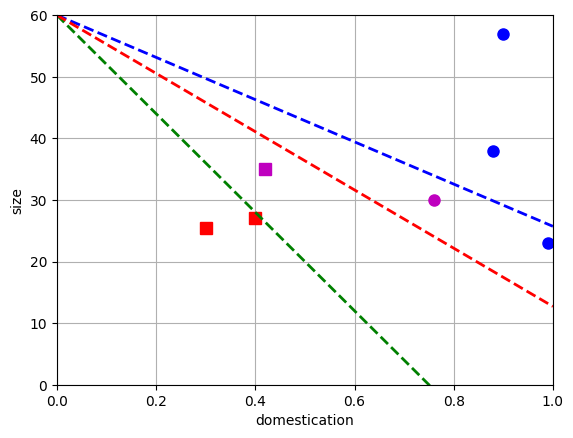

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


""" Katzen """


# Katze Attribute

cats=np.array([(0.3,0.4), (25.4, 27)])
print("Cat array \n")
print('Normal Hauskatzen',*cats)
print("---")

    # Übergrosse Katze

big_cats=np.array([(0.42),(35)])
print('Groß Hauskatzen',big_cats)

""" Hunde """

# Hund Attribute


dogs=np.array([(0.9,0.88,0.99),(57,38,23)])
print()
print("Dog arrays \n")
print('Hunde',*dogs)
print("----")

# Klein Hund

small_dogs=np.array([(0.76),(30)])
print('Klein Hunde',small_dogs)





x=np.linspace(0,1,10)
print()
m=-80 # Anstieg
b=60 # Schnittpunkt
y=m*x+b # Formel für die Entscheidungsgrenze

# Seperate achsen Werte für X und Y

dogs_domestication=dogs[0,:]
dogs_size=dogs[1,:]
cats_domestication=cats[0,:]
cats_size=cats[1,:]

plt.rcParams['lines.markersize'] = 8
plt.rcParams['lines.linewidth'] = 2
plt.axis([0,1,0,60])
plt.xlabel('domestication')
plt.ylabel("size")
plt.grid()

plt.plot(dogs_domestication,dogs_size,'bo')
plt.plot(cats_domestication,cats_size,'rs')
plt.plot(big_cats[0],big_cats[1], 'ms')
plt.plot(small_dogs[0],small_dogs[1],'mo')
plt.plot(x,y, 'g', linestyle='--')







""" Lernrate """

learning_rate=1


def update_m(m,b,x,new_data_point,label):
    if label==0: #Hunde
        y_target=new_data_point[1]-1
        line_color = 'red'
    else: # Katzen
        y_target=new_data_point[1]+1
        line_color = 'blue'


    y_is=new_data_point[0]*m+b

# Fehler

    error=(y_target-y_is)
    delta_m=(error/new_data_point[0])*learning_rate
    m_new=m+delta_m
    y_new=x*m_new+b
    plt.plot(x,y_new,color=line_color,linestyle='--')
    
    
    return m_new


m = update_m(m, b, x, big_cats, 1)

print(f"New Value Big Cats: {m}\n")

m= update_m(m,b,x,small_dogs,0)

print(f"New Value Small Dogs: {m}\n")



plt.show()
